In [1]:
import re, sys
import functools
import numpy as np
#from graphviz import Digraph, Source
from pathlib import Path
from pynini import Weight

from wyfst import config as wyconfig
from wyfst.wywrapfst import *

In [7]:
help(wyconfig)
symtable, syms = wyconfig.init({'sigma': ['a', 'b', 'c']})

Help on module wyfst.config in wyfst:

NAME
    wyfst.config

FUNCTIONS
    get_symbols(symtable_)

    init(param={})
        Set globals with dictionary or module.

    make_symtable(sigma=[])
        Create symbol table from symbol collection.

    print_symbols = print_symtable(symtable_)
        Print SymbolTable / SymbolTableView as
        (symbol_id, symbol) pairs.
        see pynini.SymbolTableView.write_text

    print_symtable(symtable_)
        Print SymbolTable / SymbolTableView as
        (symbol_id, symbol) pairs.
        see pynini.SymbolTableView.write_text

DATA
    bos = '⋊'
    eos = '⋉'
    eps = 'ϵ'
    epsilon = 'ϵ'
    logger = <Logger wyfst.config (WARNING)>
    sigma = ['a', 'b', 'c']
    special_syms = []
    syms = ['ϵ', '⋊', '⋉', 'a', 'b', 'c']
    symtable = <SymbolTable '<unspecified>'>
    unk = '⊥'
    verbosity = 0
    λ = ''

FILE
    /home/colin/Code/Python/wyfst/wyfst/config.py




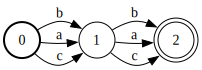

In [8]:
M = braid(2, arc_type='log')
one = Weight('log', 0.0)
M.assign_weights(lambda M, q, t: one)

M.viz()

In [9]:
beta = shortestdistance(M, reverse=True)
beta = np.array([float(w) for w in beta])
print(np.exp(-beta))

[9.00000038 3.00000006 1.        ]


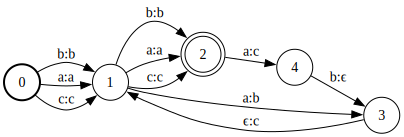

In [10]:
# Add paths.
M.add_path(src=1, ilabel='a', olabel='b c', weight=None, dest=1)
M.add_path(src=2, ilabel='a b', olabel='c', weight=None, dest=3)
M.viz()

0	1	⋊	⋊
1	2	a	a
2

0	1	b	b
1	2	⋉	⋉
2

(0, 1)	(1, 1)	⋊	⋊
(1, 1)	(2, 1)	a	a
(2, 1)	(0, 2)	ϵ	ϵ
(0, 2)	(1, 2)	b	b
(1, 2)	(2, 2)	⋉	⋉
(2, 2)

['⋊ a b ⋉']

0	(0, 1)	ϵ	ϵ
0	(0, 2)	ϵ	ϵ
(0, 1)	(1, 1)	⋊	⋊
(1, 1)	(2, 1)	a	a
(2, 1)
(0, 2)	(1, 2)	b	b
(1, 2)	(2, 2)	⋉	⋉
(2, 2)

['b ⋉', '⋊ a']


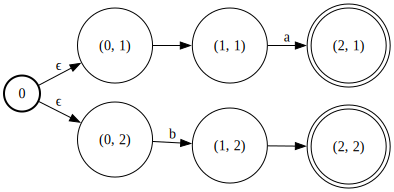

In [12]:
# Concatenation, union, optionality, star.
wfst1 = accep(f'{config.bos} a', isymbols=symtable, add_delim=False)
# wfst1 = Wfst()
# q0 = wfst1.add_state(initial=True)
# q1 = wfst1.add_state(final=True)
# wfst1.add_arc(q0, 'a', 'a', None, q1)
wfst1.print()

wfst2 = accep(f'b {config.eos}', isymbols=symtable, add_delim=False)
# wfst2 = Wfst()
# q0 = wfst2.add_state(initial=True)
# q1 = wfst2.add_state(final=True)
# wfst2.add_arc(q0, 'b', 'b', None, q1)
wfst2.print()

# Concatenation.
wfst_ = concat(wfst1, wfst2)
wfst_.print()
print(list(wfst_.accepted_strings(delete_epsilon=True)))
print()

# # Union.
wfst_ = union(wfst1, wfst2)
wfst_.print()
print(list(wfst_.accepted_strings(delete_epsilon=True)))
wfst_.viz()

# # Optionality.
# wfst = ques(wfst1)
# print(wfst.print())

# # Star.
# wfst = star(wfst1)
# print(wfst.print())

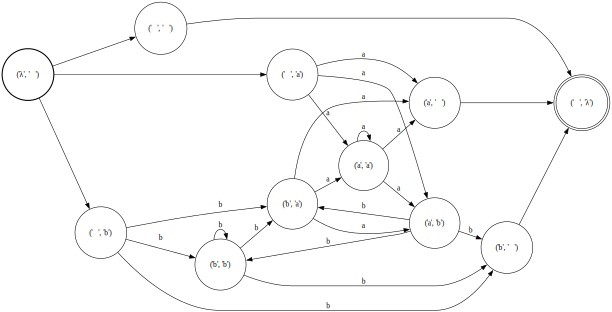

In [13]:
# N-gram machines.
config.init({'sigma': ['a', 'b']})
M = ngram(context='both', length=1)

# Flatten labels.
def relabel_func(wfst, q):
    label = wfst.state_label(q)
    label_ = tuple(' '.join(x) for x in label)
    return label_
M = M.relabel_states(relabel_func)

M.viz()

0	1	b_0	b_0
1	2	a_1	a_1
2	3	b_2	b_2
3

0	1	b	b
1	2	a	a
2	3	b	b
3

(0, 0)	(1, 1)	b_0	b
(1, 1)	(2, 2)	a_1	a
(2, 2)	(3, 3)	b_2	b
(3, 3)



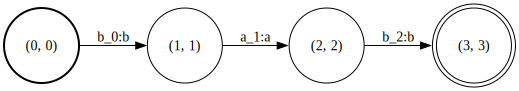

In [14]:
# Matching functions in compose().
input_ = 'bab'
input_ = [f'{x}_{i}' for i, x in enumerate(input_)]
isymbols = set(input_)
input_ = accep(' '.join(input_), isymbols)
input_.print()

output_ = 'bab'
output_ = [x for x in output_]
osymbols = set(output_)
output_ = accep(' '.join(output_), osymbols)
output_.print()

M = compose(input_, output_, matchfunc1 = lambda x : re.sub('_[0-9]+$', '', x))
M.print()
M.viz()

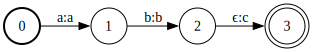

In [17]:
# String map.
M = string_map([('a b', 'a b c')])
M.viz()

In [19]:
# Treatment of output epsilons in composition.
symtable, syms = config.init({'sigma': ['a', 'b']})
M = ngram(context='both', length=1)
M.viz()

input_ = f'a {config.epsilon} b'
I = accep(input_, isymbols=symtable)
I.viz()

A = compose(M, I)
A.viz()

0	1	ϵ	ϵ
1	2	a	a
2	3	a	a
3



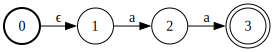

In [20]:
# Shortest (Viterbi) path.
A1 = accep('a a', isymbols=symtable, arc_type='standard', weight=Weight('tropical', 0.0))
A2 = accep('a b', isymbols=symtable, arc_type='standard', weight=Weight('tropical', 1.0))
A = union(A1, A2)

A_best = shortestpath(A)
A_best.print()

A.viz()
A_best.viz()

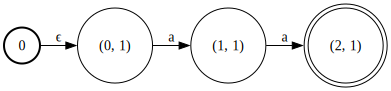

In [21]:
A_best = shortestpath_(A).connect()
A_best.viz()